In [ ]:
import pandas as pd

#carico i file csv
df_general = pd.read_csv('GeneralEsportData.csv')
df_historical = pd.read_csv('HistoricalEsportData.csv')


In [ ]:
df_historical.info() 

<class 'pandas.DataFrame'>
RangeIndex: 10239 entries, 0 to 10238
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         10239 non-null  str    
 1   Game         10239 non-null  str    
 2   Earnings     10239 non-null  float64
 3   Players      10239 non-null  int64  
 4   Tournaments  10239 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 400.1 KB


In [8]:
df_historical.describe()

,Date,Earnings,Players,Tournaments,Anno
count,10239,1.023900e+04,10239.000000,10239.000000,10239.000000
mean,2017-05-30 10:40:45.004395,1.862778e+05,61.525051,6.565192,2016.942866
min,1998-01-01 00:00:00,0.000000e+00,0.000000,1.000000,1998.000000
25%,2014-06-01 00:00:00,1.206860e+03,6.000000,1.000000,2014.000000
50%,2018-10-01 00:00:00,1.175000e+04,17.000000,2.000000,2018.000000
75%,2021-07-01 00:00:00,7.756945e+04,53.000000,6.000000,2021.000000
max,2024-10-01 00:00:00,4.014065e+07,2134.000000,172.000000,2024.000000
std,NaN,9.854799e+05,136.079728,12.055580,5.367921


Quanti soldi hanno guadagnato gli esports ogni anno dal 2019 ad oggi?

In [ ]:
df_historical.head() 

,Date,Game,Earnings,Players,Tournaments
0,1998-01-01,Command & Conquer: Red Alert,15000.0,8,1
1,1998-01-01,QuakeWorld,15000.0,8,1
2,1998-05-01,Quake II,15000.0,4,1
3,1998-05-01,Total Annihilation,15000.0,2,1
4,1998-05-01,QuakeWorld,300.0,3,1


ho creato una nuova tabella chiamata df_filtro df_covid_oggi filtrando dall'anno 2019 in poi, e mette in mostra 'Anno', 'Game', 'guadagno', 'Players', 'Tournaments

In [ ]:
df_historical['Date'] = pd.to_datetime(df_historical['Date']) #legge la colonna date e lo converto ad una data vera
df_historical['Anno'] = df_historical['Date'].dt.year #legge la data ma solamente l'anno e creo una nuova colonna anno e la aggiungo alla mia tabella
df_covid_oggi = df_historical[df_historical['Anno'] >= 2019].copy() #creo una nuova tabella chiamata df_filtro df_covid_oggi e metto un controllo se il torneo è stato fatto dall'anno 2019 in poi e fa una copia senza che modifica i dati originali
df_covid_oggi[['Anno', 'Game', 'Earnings', 'Players', 'Tournaments']].head() #mostra solo le 5 colonne specifiche

,Anno,Game,Earnings,Players,Tournaments
5320,2019,Dota 2,1503477.01,237,14
5321,2019,Overwatch,1035800.98,602,11
5322,2019,Counter-Strike: Global Offensive,903881.05,491,106
5323,2019,PLAYERUNKNOWN’S BATTLEGROUNDS,639888.97,194,7
5324,2019,Arena of Valor,539124.00,46,2


In [31]:
import pandas as pd

df_covid_italia = pd.read_csv('esports_italia_fan.csv')

mostra le colonne del periodo, fan_totali, la percentuale degli spettatori regolari/ spettatori regolari

In [32]:
import pandas as pd

df_covid_italia.head()

,Periodo,Fan_Tot_Milioni,Spett_Regolari_Sett_Percentage,Spett_Regolari_Milioni
0,Pre-Covid (2019),6.0,15,1.2
1,Covid (2020),6.7,23,1.4
2,Oggi (2024),7.3,17,3.3


creo una grafica per vedere il peak di spettatori regolari durante il covid

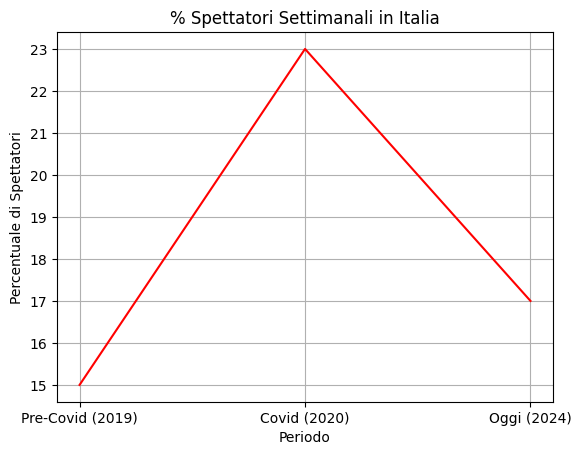

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_covid_italia['Periodo'], df_covid_italia['Spett_Regolari_Sett_Percentage'], color='red')

plt.title('% Spettatori Settimanali in Italia')
plt.xlabel('Periodo')
plt.ylabel('Percentuale di Spettatori')
plt.grid(True)

plt.show()

a causa del covid, sono stati cancellati tutti i tornei dal vivo, quindi gli sponsor sono diminuiti e meno investimenti.
visto che le persone erano chiuse in casa tantissimi italiani hanno iniziato a guardare i tornei su twitch/ youtube
nel 2024 il numero di fan totali in italia sono diminuiti ma è diventato più grande rispetto a prima del Covid.

Le Piattaforme Streaming più usate in Italia

In [40]:
import pandas as pd

df_piattaforme = pd.read_csv('esports_italia_piattaforme.csv')
print(df_piattaforme)

  Piattaforma  Percentage_Utilizzo_Italia
0     YouTube                          47
1      Twitch                          46
2        Kick                          31
3      Tiktok                          29
4    Facebook                          20


Text(0, 0.5, 'Piattaforma')

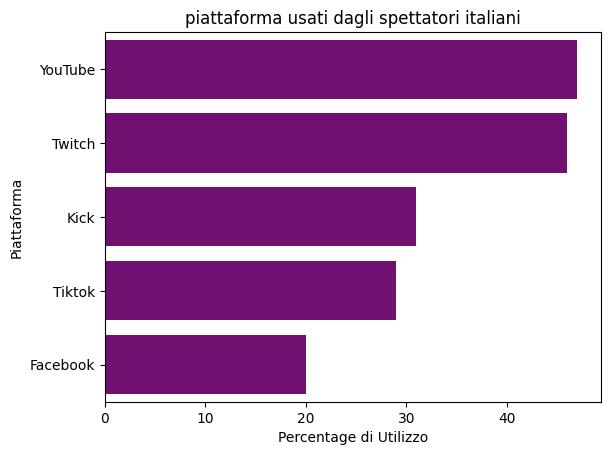

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.barplot(x='Percentage_Utilizzo_Italia', y='Piattaforma', data=df_piattaforme, color='purple')

plt.title('piattaforma usati dagli spettatori italiani')
plt.xlabel('Percentage di Utilizzo')
plt.ylabel('Piattaforma')

mostra le 5 piattaforme che vengono utilizzati per guardare le partite di esports in italia
youtube e twitch in praticamente nello stesso livello seguite poi da kick, tiktok e infine facebook

In [ ]:
import pandas as pd

df_machlearning = df_covid_oggi[['Game', 'Earnings', 'Tournaments']].copy() #creo una nuova tabella utilizzando di partenza la tabella df_covid_oggi


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df_covid_oggi[['Earnings', 'Tournaments']]
y = df_covid_oggi['Game'].str.lower().str.contains('valorant|strike|duty').astype(int) # se il nome del gioco contiene 'valorant', 'strike' o 'duty', assegna 1, altrimenti 0

modello = RandomForestClassifier(random_state=42)

modello.fit(X, y)
previsioni = modello.predict(X)
voto = accuracy_score(y, previsioni)

punteggio = modello.score(X, y)
print(f"Precisione: {punteggio * 100:.1f}%")



Precisione del modello: 68.6%
